Week 8 (16/04/2025) - Object classification

Book classification exercise using feature extraction.

In [ ]:
import numpy as np
import cv2

# Start by picking the training images for classification.
images = [] # create a Python list containing the dataset

img = cv2.imread("/home/gianmaria/01-Data/tomb.jpg") # get the Tomb Raider image
images.append(img)

img = cv2.imread("/home/gianmaria/01-Data/dnd.jpg") # get the Dungeons and Dragons image
images.append(img)

img = cv2.imread("/home/gianmaria/01-Data/ghost.jpg") # get the Ghost image
images.append(img)

# Then, create a list containing the class names of the dataset.
classes = ["Tomb Raider", "DnD", "Ghost Impera"]

# At this point, create a descriptor database to use for comparisons during the testing stage.
def descriptorsDB(images):
    descriptors_list = [] # database containing the extracted descriptors
    # Create an instance of the ORB feature extractor.
    orb = cv2.ORB_create(nfeatures=1000) # let the ORB extractor pick 1000 features from each image
    # Extract and store the descriptors of the images.
    for image in images:
        kpt, des = orb.detectAndCompute(image, None) # no mask is specified in this case, so describe the whole region
        descriptors_list.append(des)
    return descriptors_list

# Create a function to do the matches for classification.
def objClassification(frame, descriptors_list):
    # Create an instance of the ORB feature extractor.
    orb = cv2.ORB_create(nfeatures=1000)
    kpt, des = orb.detectAndCompute(frame, None)
    # Create the matcher.
    matcher = cv2.BFMatcher()
    best_matches = []
    # Perform the actual matches.
    for dsc in descriptors_list:
        matches = matcher.knnMatch(des, dsc, k=2) # perform k nearest neighbours for k = 2
        good = []
        for m,n in matches:
            if m.distance < n.distance * 0.8:
                good.append([m])
        best_matches.append(len(good)) # the correct class will be the one giving the highest number of matches
    # Lastly, get the class ID.
    classID = None # initialize the ID to None to handle the case in which there is no match
    if len(best_matches) > 0:
        max_val = max(best_matches) # get the best match
        # Define a threshold to reduce the number of false positives.
        if max_val > 10:
            classID = best_matches.index(max_val) # set the ID to the position of the maximum value within the best matches
    return classID

# Provide the images to the program for the testing stage.
# This can be done in two ways: load the image from the disk or provide the image in real time by using a webcam.

# Start by creating the feature database.
descriptors_list = descriptorsDB(images)

# Create the webcam approach.
webcam = cv2.VideoCapture(0) # create a Python object to access the webcam (the input specifies the index/internet/path stream)

# For streaming, create an infinite loop that can be stopped only manually by pressing a key.
while True:
    # Start by reading frames from the stream.
    success, frame = webcam.read() # return whether the frame has been read correctly along with the actual frame
    obj_id = objClassification(frame, descriptors_list) # get the frame's ID
    if obj_id != None:
        cv2.putText(frame, classes[obj_id], (50, 50), cv2.FONT_HERSHEY_COMPLEX, 1, (0, 0, 255), 1) # write the class on the frame
    # Show the extracted frame.
    cv2.imshow("Frame", frame)
    k = cv2.waitKey(30) # derive the key that was pressed
    if k == ord("q"):
        # Check the key: if the pressed key is "q" (quit), then break the loop.
        break

Exercise on supervised learning: classifying hand-written digits.

0.8277777777777777


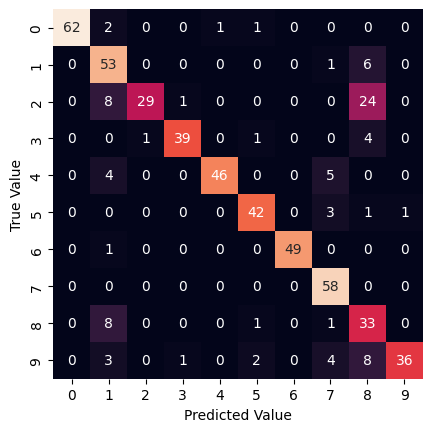

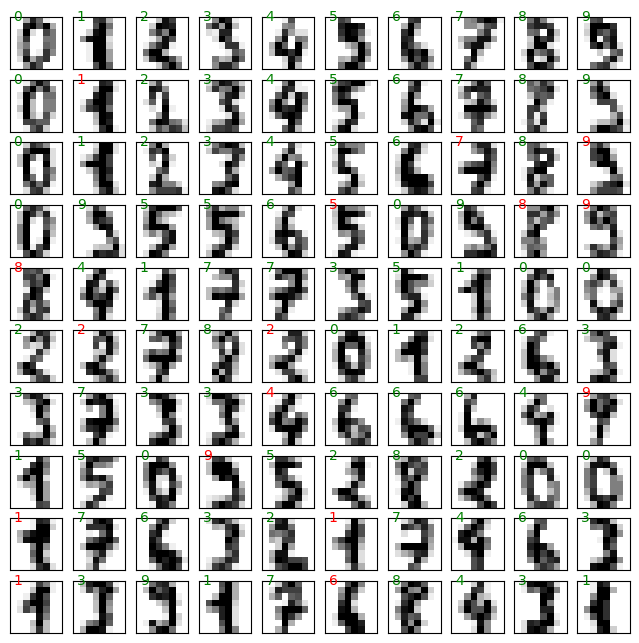

In [6]:
from sklearn.datasets import load_digits # to load the dataset
import matplotlib.pyplot as plt
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Start by loading the datatset, which will contain 1797 samples of 8x8 grayscale images of hand-written digits (0-9).
digits = load_digits()
# print(digits.images.shape) # to get the number of sample images and their dimensions

'''
# Plot some elements of the dataset.
figs, axes = plt.subplots(10, 10, figsize=(8, 8), subplot_kw={'xticks':[], 'yticks':[]})
for i,ax in enumerate(axes.flat): # loop over each subplot
    ax.imshow(digits.images[i], cmap='binary') # show the binary images
    ax.text(0.05, 0.05, str(digits.target[i]), color='green') # print the label along with the image
plt.show()
'''

# Notice that the shape of the digits dataset does not make it compatible with Scikit-Learn because the samples are two-dimensional.
# However, it is possible to fix this issue by feature extraction or by reshaping images into one-dimensional arrays.
# Alternatuvely, it is possible to use the data attribute in order to get the data without any issues.
X = digits.data # get the samples and the corresponding features
y = digits.target # get the labels
# print(X.shape) # to see the chnge in dimensionality

# At this point, split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7) # 70% training, 30% testing, no random state

# Define the instance of the Gaussian Naive Bayes model.
model = GaussianNB()

# Train the model by fitting the training set.
model.fit(X_train, y_train)

# Use the model for predicting new testing data.
y_predictions = model.predict(X_test)

# Compute the accuracy of the model using the predictions.
accuracy = accuracy_score(y_test, y_predictions)
print(accuracy)

# Generally speaking, it is possible to spot the problematic data using a confusion matrix.
# A confusion matrix contains both the predicted labels and the real labels.
# This means that mat[i, j] counts how many points predicted to have label i actually have label j.
# In particular, mat[i, i] represents correct predictions, whereas mat[i, j] represents wrong predictions.
mat = confusion_matrix(y_test, y_predictions)
sns.heatmap(mat, square=True, annot=True, cbar=False) # plot the matrix showing squares and annotations
plt.xlabel("Predicted Value")
plt.ylabel("True Value")
plt.show()

# Plot the pronlematic samples.
figs, axes = plt.subplots(10, 10, figsize=(8, 8), subplot_kw={'xticks':[], 'yticks':[]})
for i,ax in enumerate(axes.flat): # loop over each subplot
    ax.imshow(digits.images[i], cmap='binary') # show the binary images
    ax.text(0.05, 0.05, str(digits.target[i]), color='green' if (y_test[i] == y_predictions[i]) else 'red') # print the label along with the image
plt.show()